**EDA TODOs**

- **Data overview:**
  - Quick glance: `data.shape`, `data.info()`, `data.head()`
  - Check duplicates (by `case_number`, `href`, full row)
  - Confirm dtypes and convert where needed (`normalized` → datetime, `year` → int)

- **Missing values / completeness:**
  - Per-column missing-count and % missing
  - Investigate columns with many missing values (`age`, `time`, `species`, `state`)
  - Decide strategy: drop, flag, or impute

- **Univariate — Numerical:**
  - `year`, `age`, `original_order`: summary stats, histograms
  - Detect outliers (IQR / z-score) for `age`
  - Time coverage: min/max/median year, per-decade counts

- **Univariate — Categorical:**
  - Value counts and top-10 for `type`, `country`, `state`, `activity`, `species`, `sex`, `fatal_y_n`
  - Rare categories: flag or group as "Other"
  - Normalize inconsistent labels (e.g., `fatal_y_n` variations)

- **Date / Time analysis:**
  - Incidents per year / month / weekday
  - Seasonality (by month or meteorological seasons)
  - Time-of-day distribution (clean/normalize `time` first)

- **Geographic:**
  - Top countries and states by incidents
  - Map view (if lat/lon available or geocode `location`) — choropleth or scatter map

- **Bivariate — Categorical vs Categorical:**
  - Cross-tab: `type` vs `fatal_y_n`, `activity` vs `injury`, `sex` vs `fatal_y_n`
  - Stacked bar charts or heatmaps for co-occurrence

- **Bivariate — Categorical vs Numerical:**
  - `age` distribution by `fatal_y_n`, `sex`, `type`
  - Mean/median `age` per `activity` / `species`

- **Bivariate — Time series / Trends:**
  - Yearly trend by `type` and by `country`
  - Rolling averages (5- or 10-year) to smooth noise
  - Anomaly detection for spikes/sudden drops

- **Multivariate / Correlation:**
  - Correlation matrix for numeric columns
  - Pairplots for small numeric subsets
  - Logistic-style checks: predictors vs fatality (for simple modeling)

- **Text / Freeform fields:**
  - Quick keyword extraction from `species`, `activity`, `location`, `source` (e.g., cluster similar labels)
  - Normalize common terms and typos

- **Quality checks & metadata:**
  - Rows where `normalized` date differs drastically from `Date_orig`
  - Verify `Year` matches `normalized.year` (after fill)
  - Save indices of suspicious rows (already written to `idx.csv`)

- **Deliverables / outputs to create:**
  - Cleaned dataset CSV/Excel
  - Summary notebook cells with plots and tables
  - Interactive map and interactive time-series (Plotly HTML export)


If you want, I can now implement a subset (pick 2–4) and add the corresponding code cells: e.g., (A) missing-value report + top-value counts, (B) age distribution and outlier table, (C) cross-tab `type` vs `fatal_y_n`, (D) map of incidents by country. Which ones shall I add next?

In [286]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [287]:
data = pd.read_csv("normalized_dates.csv", index_col="Unnamed: 0")
data.head()

,date,year,type,country,state,location,activity,name,sex,age,injury,fatal_y_n,time,species,source,pdf,href_formula,href,case_number,case_number_1,original_order,unnamed_21,unnamed_22,date_orig,normalized,is_exact_date,date_from,date_to,date_extra
0,2026-01-29,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,Right thigh and lower leg stripped of flesh,Y,?,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29th January,2026-01-29 00:00:00,False,NaN,2026-01-29 00:00:00,NaN
1,2026-01-29,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,No injury shark knocked man of his board,N,1100hrs,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29th January,2026-01-29 00:00:00,False,NaN,2026-01-29 00:00:00,NaN
2,2026-01-24,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,Puncture wounds to right knee,N,1815hrs,1.7m Seven Gill shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24th January,2026-01-24 00:00:00,False,NaN,2026-01-24 00:00:00,NaN
3,2026-01-20,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,Minor cuts and abrasions,N,0830hrs,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20th January,2026-01-20 00:00:00,False,NaN,2026-01-20 00:00:00,NaN
4,2026-01-19,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,None reported damage to board,N,1145hrs,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19th January,2026-01-19 00:00:00,False,NaN,2026-01-19 00:00:00,NaN


In [288]:
data.sex.unique()

<StringArray>
['M', 'F', 'F ', 'M ', nan, ' M', 'm', 'lli', '?', 'M x 2', 'N', '.']
Length: 12, dtype: str

In [289]:

# helper to clean/expand sex column
import re

def normalize_sex(df, sex_col='sex', name_col='name'):
    """Standardize sex values and expand rows with multiplicity markers.

    - Strips/uppercases values and maps to 'M', 'F', or 'O' (other/unknown).
    - Handles strings like 'M x 2' by splitting the name field on '&' or ' and '
      and emitting two rows (one per victim) with the base sex.
    """
    records = []
    for _, row in df.iterrows():
        raw = str(row.get(sex_col, '')).strip().upper()
        # multiplicity indicator
        m = re.match(r'^([MF])\s*[X×]\s*(\d+)$', raw)
        if m:
            base = m.group(1)
            qty = int(m.group(2))
            # split names if possible
            names = re.split(r'\s*&\s*|\s+AND\s+', str(row.get(name_col, '')))
            if len(names) >= qty:
                for nm in names[:qty]:
                    newrow = row.copy()
                    newrow[name_col] = nm.strip()
                    newrow[sex_col] = base
                    records.append(newrow)
                continue
            else:
                # nothing to split, just duplicate blank names
                for i in range(qty):
                    newrow = row.copy()
                    newrow[sex_col] = base
                    records.append(newrow)
                continue
        # normal case: map value
        if raw in ('M', 'MALE'):
            norm = 'M'
        elif raw in ('F', 'FEMALE'):
            norm = 'F'
        else:
            norm = 'O'
        row[sex_col] = norm
        records.append(row)
    return pd.DataFrame(records).reset_index(drop=True)

# apply to current dataframe and show value counts before/after
print('before:', data["sex"].value_counts(dropna=False))
data = normalize_sex(data)
print('after :', data["sex"].value_counts(dropna=False))


before: sex
M        5588
F         800
NaN       564
M           4
F           2
N           2
 M          1
m           1
lli         1
?           1
M x 2       1
.           1
Name: count, dtype: int64
after : sex
M    5596
F     802
O     569
Name: count, dtype: int64


In [290]:
# Normalize `type` column to: unprovoked, provoked, invalid, watercraft, sea disaster
import re

def normalize_type(df, type_col='type'):
    """Normalize values in `type_col` per mapping rules:
    - unconfirmed == unverified == questionable == invalid -> 'invalid'
    - boat == watercraft -> 'watercraft'
    - Under investigation == unprovoked -> 'unprovoked'
    - allowed final values: 'unprovoked','provoked','invalid','watercraft','sea disaster'
    """
    def map_type(x):
        if pd.isna(x):
            return 'invalid'
        s = str(x).strip().lower()
        if s in ('', 'nan', 'none', '?', 'unknown'):
            return 'invalid'
        # normalize spacing/punctuation
        s_clean = re.sub(r'[\-_/]+', ' ', s)

        # direct mappings and substring checks
        if 'under investigation' in s_clean:
            return 'unprovoked'
        if s_clean in ('unconfirmed', 'unverified', 'questionable', 'invalid'):
            return 'invalid'
        if 'unconfirm' in s_clean or 'unverif' in s_clean or 'question' in s_clean:
            return 'invalid'
        if 'unprovok' in s_clean or s_clean == 'unprovoked':
            return 'unprovoked'
        if 'provok' in s_clean or s_clean == 'provoked':
            return 'provoked'
        if 'boat' in s_clean or 'watercraft' in s_clean:
            return 'watercraft'
        if 'sea' in s_clean and 'disaster' in s_clean:
            return 'sea disaster'
        # fallback: if contains 'sea disaster' words
        if 'sea' in s_clean and 'ship' in s_clean:
            return 'sea disaster'
        # everything else -> invalid
        return 'invalid'

    df[type_col] = df[type_col].apply(map_type)
    return df

# show before/after counts
print('before type counts:')
print(data['type'].value_counts(dropna=False))

data = normalize_type(data)
print('\nafter type counts:')
print(data['type'].value_counts())


before type counts:
type
Unprovoked             5157
Provoked                636
Invalid                 553
Watercraft              348
Sea Disaster            234
Questionable             26
Boat                      7
 Provoked                 2
unprovoked                1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64

after type counts:
type
unprovoked      5159
provoked         638
invalid          581
watercraft       355
sea disaster     234
Name: count, dtype: int64


In [291]:
# Normalize `fatal_y_n` column to: 'Y', 'N', 'Unknown'
import re

def normalize_fatal(df, col='fatal_y_n'):
    """Normalize fatality column values.

    Rules:
    - Map variants of yes/fatal to 'Y' (e.g., 'Y', 'y', 'Y x 2', 'F', 'fatal')
    - Map variants of no/non-fatal to 'N' (e.g., 'N', 'n', 'Nq', 'M')
    - Unknown/empty/'?'/nan -> 'Unknown'
    """
    def map_val(v):
        if pd.isna(v):
            return 'Unknown'
        s = str(v).strip().lower()
        if s in ('', 'nan', 'none', '?', 'unknown', 'u'):
            return 'Unknown'
        # multiplicity like 'y x 2' or 'Y x2' -> take base
        m = re.match(r"^([a-z])\s*[x×]\s*\d+$", s)
        if m:
            s = m.group(1)
        # map final
        if s in ('y', 'yes', 'f', 'fatal'):
            return 'Y'
        if s in ('n', 'no', 'nq', 'm'):
            return 'N'
        # some messy values: treat single-letter f as fatal, m as no
        if s == 'y x 2':
            return 'Y'
        return 'Unknown'

    df[col] = df[col].apply(map_val)
    return df

# show before/after
print('before counts:')
print(data['fatal_y_n'].value_counts(dropna=False))

data = normalize_fatal(data)
print('\nafter counts:')
print(data['fatal_y_n'].value_counts(dropna=False))


before counts:
fatal_y_n
N          4884
Y          1441
NaN         553
UNKNOWN      68
 N            7
F             5
M             2
Y x 2         2
n             1
Nq            1
2017          1
N             1
y             1
Name: count, dtype: int64

after counts:
fatal_y_n
N          4896
Y          1449
Unknown     622
Name: count, dtype: int64


In [292]:
# Normalize `country` values to common country names; map regions/oceans -> Unknown
import re

def normalize_country(df, col='country'):
    """Normalize country names using common mappings and heuristics.

    - Returns standardized country names (title case) for common countries.
    - Maps known variants/typos to canonical names.
    - Regions/oceans/sea/gulf entries are mapped to 'Unknown'.
    """
    # mapping keys are uppercase cleaned forms -> canonical title-case name
    mapping = {
        'USA': 'United States',
        'UNITED STATES': 'United States',
        'U.S.A.': 'United States',
        'U S A': 'United States',
        'HAWAII': 'United States',
        'AUSTRALIA': 'Australia',
        'AUSTRALIA ': 'Australia',
        'NEW ZEALAND': 'New Zealand',
        'NEW CALEDONIA': 'New Caledonia',
        'FRENCH POLYNESIA': 'French Polynesia',
        'PHILIPPINES': 'Philippines',
        'PHILIPPINES ': 'Philippines',
        'MALDIVES': 'Maldives',
        'MALDIVE ISLANDS': 'Maldives',
        'MALDIVE ISLAND': 'Maldives',
        'INDONESIA': 'Indonesia',
        'INDIA': 'India',
        'BRAZIL': 'Brazil',
        'ARGENTINA': 'Argentina',
        'CHINA': 'China',
        'JAPAN': 'Japan',
        'MEXICO': 'Mexico',
        'MeXICO': 'Mexico',
        'MEXICO ': 'Mexico',
        'COSTA RICA': 'Costa Rica',
        'COLUMBIA': 'Colombia',
        'COLOMBIA': 'Colombia',
        'ECUADOR': 'Ecuador',
        'PERU': 'Peru',
        'VENEZUELA': 'Venezuela',
        'UNITED KINGDOM': 'United Kingdom',
        'ENGLAND': 'United Kingdom',
        'SCOTLAND': 'United Kingdom',
        'IRELAND': 'Ireland',
        'CANARY ISLANDS': 'Spain',
        'SPAIN': 'Spain',
        'PORTUGAL': 'Portugal',
        'FRANCE': 'France',
        'ITALY': 'Italy',
        'GREECE': 'Greece',
        'TURKEY': 'Turkey',
        'EGYPT': 'Egypt',
        'EGYPT ': 'Egypt',
        'SOUTH AFRICA': 'South Africa',
        'SOUTH KOREA': 'South Korea',
        'KENYA': 'Kenya',
        'MADAGASCAR': 'Madagascar',
        'MOZAMBIQUE': 'Mozambique',
        'MAURITIUS': 'Mauritius',
        'SEYCHELLES': 'Seychelles',
        'VANUATU': 'Vanuatu',
        'FIJI': 'Fiji',
        'SAMOA': 'Samoa',
        'TONGA': 'Tonga',
        'PAPUA NEW GUINEA': 'Papua New Guinea',
        'NEW GUINEA': 'Papua New Guinea',
        'PAPUA NEW GUINEA': 'Papua New Guinea',
        'AUSTRIA': 'Austria',
        'CAYMAN ISLANDS': 'Cayman Islands',
        'BAHAMAS': 'Bahamas',
        'PUERTO RICO': 'Puerto Rico',
        'TURKS AND CAICOS': 'Turks and Caicos',
        'TURKS & CAICOS': 'Turks and Caicos',
        'TURKS and CAICOS': 'Turks and Caicos',
        'TRINIDAD & TOBAGO': 'Trinidad and Tobago',
        'TRINIDAD': 'Trinidad and Tobago',
        'JAMAICA': 'Jamaica',
        'BELIZE': 'Belize',
        'HONDURAS': 'Honduras',
        'NICARAGUA': 'Nicaragua',
        'COSTA RICA': 'Costa Rica',
        'PANAMA': 'Panama',
        'BERMUDA': 'Bermuda',
        'CUBA': 'Cuba',
        'DOMINICAN REPUBLIC': 'Dominican Republic',
        'ARUBA': 'Aruba',
        'CURACAO': 'Curacao',
        'ANTIGUA': 'Antigua and Barbuda',
        'BARBADOS': 'Barbados',
        'ST KITTS / NEVIS': 'Saint Kitts and Nevis',
        'ST. KITTS/NEVIS': 'Saint Kitts and Nevis',
        'ST MARTIN': 'Saint Martin',
        'ST. MARTIN': 'Saint Martin',
        'ST. MAARTIN': 'Saint Martin',
        'SAINT MARTIN': 'Saint Martin',
        'NEVIS': 'Saint Kitts and Nevis',
        'BRITISH VIRGIN ISLANDS': 'British Virgin Islands',
        'US VIRGIN ISLANDS': 'United States Virgin Islands',
        'BRITISH WEST INDIES': 'Caribbean',
        'WEST INDIES': 'Caribbean',
        'CARIBBEAN SEA': 'Caribbean',
        'CARIBBEAN': 'Caribbean',
        'ATLANTIC OCEAN': 'Unknown',
        'PACIFIC OCEAN': 'Unknown',
        'SOUTH PACIFIC OCEAN': 'Unknown',
        'NORTH PACIFIC OCEAN': 'Unknown',
        'MID PACIFIC OCEAN': 'Unknown',
        'INDIAN OCEAN': 'Unknown',
        'SOUTH CHINA SEA': 'Unknown',
        'NORTH ATLANTIC OCEAN': 'Unknown',
        'GULF OF ADEN': 'Unknown',
        'PERSIAN GULF': 'Unknown',
        'RED SEA / INDIAN OCEAN': 'Unknown',
        'NORTH SEA': 'Unknown',
        'MEDITERRANEAN SEA': 'Unknown',
        'BAY OF BENGAL': 'Unknown',
        'COAST OF AFRICA': 'Unknown',
        # etc. add more as needed
    }

    def clean_val(v):
        if pd.isna(v):
            return 'Unknown'
        s = str(v).strip()
        # normalize whitespace and punctuation
        s_clean = re.sub(r"[\s\-_/\\]+", ' ', s).strip().upper()
        # common typos
        s_clean = s_clean.replace('ME XICO', 'MEXICO').replace('MALDIVE ISLANDS', 'MALDIVES')
        s_clean = s_clean.replace('MALDIVE ISLAND', 'MALDIVES')
        # remove trailing commas/spaces
        s_clean = s_clean.strip(', ')
        # direct mapping
        if s_clean in mapping:
            return mapping[s_clean]
        # try partial matches for common countries
        for k, v in mapping.items():
            if k in s_clean and v != 'Unknown':
                return v
        # if contains delimiter '/' choose the first part and try again
        if '/' in s_clean:
            first = s_clean.split('/')[0].strip()
            if first in mapping:
                return mapping[first]
        # region strings -> Unknown
        if any(term in s_clean for term in ('OCEAN', 'SEA', 'GULF', 'BAY', 'COAST', 'ATLANTIC', 'PACIFIC', 'INDIAN')):
            return 'Unknown'
        # fallback: title-case cleaned input
        try:
            return s_clean.title()
        except Exception:
            return 'Unknown'

    df[col] = df[col].apply(clean_val)
    return df

# Show before/after counts
print('before country sample counts:')
print(data['country'].nunique())

data = normalize_country(data)
print('\nafter country sample counts:')
print(data['country'].nunique())


before country sample counts:
244

after country sample counts:
160


In [293]:
# Normalize `age` column: parse ranges, split multi-person entries, generate random values
import numpy as np

def normalize_age(df, age_col='age', name_col='name'):
    """Normalize age values and expand rows with multiple ages.
    
    Also creates `age_modified` column marking True if age changed from original.
    Final age is converted to int (with NaN as is).
    """
    records = []
    np.random.seed(42)  # for reproducibility
    
    def parse_single_age(s):
        """Parse a single age string into a float value or NaN."""
        if pd.isna(s):
            return np.nan
        s = str(s).strip()
        # remove non-breaking space
        s = s.replace('\xa0', ' ').strip()
        # empty or unknown markers
        if s.lower() in ('', '?', 'm', 'unknown') or s.isspace():
            return np.nan
        s_lower = s.lower()
        
        # special single-character fixes
        if s == '!6':
            return 16.0
        if s == '!!':
            return 11.0
        
        # try direct numeric parse first
        try:
            return float(s)
        except ValueError:
            pass
        
        # handle fractional ages like "6½"
        if '½' in s or '1/2' in s:
            m = re.match(r'(\d+)', s)
            if m:
                return float(m.group(1)) + 0.5
        
        # handle "months" -> convert to years
        if 'month' in s_lower:
            m = re.search(r'(\d+)\s*month', s_lower)
            if m:
                months = int(m.group(1))
                return months / 12.0
        
        # ranges: "X to Y", "X-Y", "X or Y"
        for delim in [' to ', '-', ' or ']:
            if delim in s:
                parts = s.split(delim)
                if len(parts) == 2:
                    try:
                        low = float(parts[0].strip())
                        high = float(parts[1].strip())
                        return np.random.uniform(low, high)
                    except ValueError:
                        pass
        
        # ranges: "X+" (e.g., "50+")
        if s_lower.endswith('+'):
            m = re.match(r'(\d+)\+', s)
            if m:
                base = int(m.group(1))
                return float(np.random.uniform(base, base + 10))
        
        # decades: "20s", "30s", etc. or "20/30"
        if re.match(r'^\d{2}s$', s_lower):
            base = int(s_lower[0:2])
            return float(np.random.uniform(base, base + 10))
        if re.match(r'^\d{2}/\d{2}$', s_lower):
            parts = s_lower.split('/')
            low = int(parts[0])
            high = int(parts[1])
            return float(np.random.uniform(low, high))
        if 'mid-' in s_lower:
            m = re.search(r'mid-(\d{2})', s_lower)
            if m:
                base = int(m.group(1))
                return float(np.random.uniform(base, base + 10))
        
        # text descriptors
        if 'middle age' in s_lower:
            return float(np.random.uniform(40, 65))
        if 'adult' in s_lower:
            return float(np.random.uniform(18, 60))
        if 'young' in s_lower:
            return float(np.random.uniform(18, 26))
        if 'teen' in s_lower:
            return float(np.random.uniform(13, 20))
        if 'minor' in s_lower:
            return float(np.random.uniform(0, 18))
        if 'elderly' in s_lower:
            return float(np.random.uniform(65, 90))
        
        return np.nan
    
    # iterate over rows and track original age
    for _, row in df.iterrows():
        raw = row.get(age_col)
        orig_age = raw  # save original
        
        # check if multi-age (contains &, 'and', or comma)
        if pd.notna(raw) and (any(sep in str(raw) for sep in ['&', ',']) or ('and' in str(raw).lower())):
            raw_str = str(raw)
            parts = re.split(r'[&,]', raw_str)
            ages = [parse_single_age(p.strip()) for p in parts]
            name_raw = row.get(name_col, '')
            name_parts = re.split(r'\&|and|,', str(name_raw))
            
            for i, age_val in enumerate(ages):
                newrow = row.copy()
                newrow[age_col] = age_val
                newrow['age_modified'] = True  # multi-age rows are always modified
                if i < len(name_parts):
                    newrow[name_col] = name_parts[i].strip()
                records.append(newrow)
        else:
            # single age
            age_val = parse_single_age(raw)
            row[age_col] = age_val
            # flag: True if value changed from original
            try:
                row['age_modified'] = not (pd.notna(orig_age) and float(orig_age) == age_val)
            except (ValueError, TypeError):
                row['age_modified'] = pd.notna(orig_age)
            records.append(row)
    
    result_df = pd.DataFrame(records).reset_index(drop=True)
    # convert age to numeric
    result_df[age_col] = pd.to_numeric(result_df[age_col], errors='coerce')
    # round to nearest int, then convert to Int64 (allows NaN)
    result_df[age_col] = result_df[age_col].round().astype('Int64')
    return result_df

# Apply normalization
print('before age normalization - total rows:', len(data))
data = normalize_age(data)
print(f'after age normalization - total rows: {len(data)}')
print(f'age dtype: {data["age"].dtype}')
print(f'rows with age_modified=True: {data["age_modified"].sum()}')
print(f'age stats:\n{data["age"].describe()}')


before age normalization - total rows: 6967
after age normalization - total rows: 6999
age dtype: Int64
rows with age_modified=True: 3085
age stats:
count       4057.0
mean     28.192753
std      14.706759
min            0.0
25%           17.0
50%           24.0
75%           37.0
max           87.0
Name: age, dtype: Float64


In [294]:
data.head()

,date,year,type,country,state,location,activity,name,sex,age,injury,fatal_y_n,time,species,source,pdf,href_formula,href,case_number,case_number_1,original_order,unnamed_21,unnamed_22,date_orig,normalized,is_exact_date,date_from,date_to,date_extra,age_modified
0,2026-01-29,2026.0,unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,Right thigh and lower leg stripped of flesh,Y,?,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29th January,2026-01-29 00:00:00,False,NaN,2026-01-29 00:00:00,NaN,False
1,2026-01-29,2026.0,unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,<NA>,No injury shark knocked man of his board,N,1100hrs,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29th January,2026-01-29 00:00:00,False,NaN,2026-01-29 00:00:00,NaN,True
2,2026-01-24,2026.0,unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,<NA>,Puncture wounds to right knee,N,1815hrs,1.7m Seven Gill shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24th January,2026-01-24 00:00:00,False,NaN,2026-01-24 00:00:00,NaN,True
3,2026-01-20,2026.0,unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,Minor cuts and abrasions,N,0830hrs,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20th January,2026-01-20 00:00:00,False,NaN,2026-01-20 00:00:00,NaN,False
4,2026-01-19,2026.0,unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,None reported damage to board,N,1145hrs,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19th January,2026-01-19 00:00:00,False,NaN,2026-01-19 00:00:00,NaN,False


In [295]:
data.fatal_y_n.unique()

<StringArray>
['Y', 'N', 'Unknown']
Length: 3, dtype: str

In [296]:
data.age.unique()

<IntegerArray>
[  13, <NA>,   39,   11,   27,   12,   26,   56,   55,   24,   25,   61,   40,
   14,   54,   48,   57,    8,   63,    9,   19,    7,   85,   69,   18,   66,
   21,   37,   16,   20,   42,   45,   30,   47,   29,   35,   58,   17,   36,
   23,   28,   38,   68,   33,   15,   41,   43,   44,   49,   46,   65,   64,
   32,   10,   62,   22,   52,   59,   50,   34,   77,   60,   73,   67,    6,
   53,   51,   31,   71,   75,   70,    4,   74,    3,   82,   72,    2,    5,
   86,   84,   87,    1,    0,   81,   78]
Length: 85, dtype: Int64

BEFORE: 6966 rows | 6813 numeric | 153 non-numeric/unknown
AFTER : 6998 rows | 4057 numeric | 2941 NaN


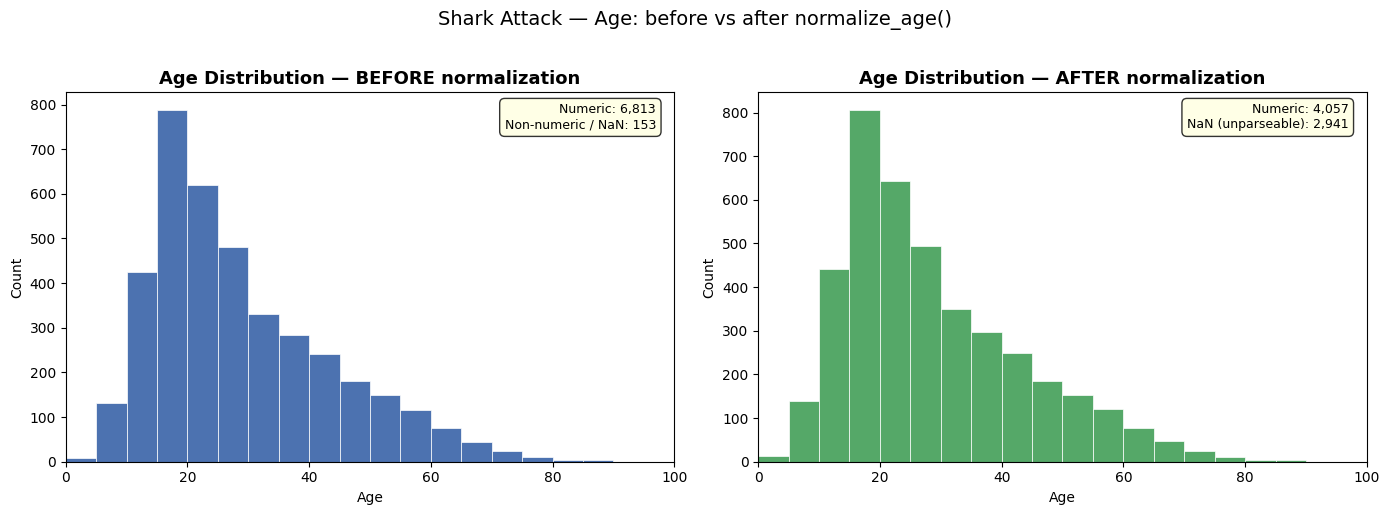

In [297]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import re

# ── 1. Load raw ages BEFORE normalization ─────────────────────────────────────
raw_df = pd.read_csv("normalized_dates.csv", index_col="Unnamed: 0")
raw_age_series = raw_df["age"].astype(str).str.strip()

def is_numeric(v):
    try:
        float(v)
        return True
    except (ValueError, TypeError):
        return False

raw_numeric_mask = raw_age_series.apply(is_numeric)
raw_ages_num = pd.to_numeric(raw_age_series[raw_numeric_mask], errors="coerce").dropna()

# ── 2. Apply normalization and get AFTER ages ─────────────────────────────────
norm_df = normalize_age(raw_df.copy())
norm_ages_num = norm_df["age"].dropna().astype(float)

# ── 3. Summary stats ──────────────────────────────────────────────────────────
total = len(raw_age_series)
non_numeric_count = total - int(raw_numeric_mask.sum())
norm_nan_count = norm_df["age"].isna().sum()

print(f"BEFORE: {total} rows | {int(raw_numeric_mask.sum())} numeric | {non_numeric_count} non-numeric/unknown")
print(f"AFTER : {len(norm_df)} rows | {len(norm_ages_num)} numeric | {norm_nan_count} NaN")

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.arange(0, 101, 5)

# Before
axes[0].hist(raw_ages_num, bins=bins, color="#4C72B0", edgecolor="white", linewidth=0.5)
axes[0].set_title("Age Distribution — BEFORE normalization", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].set_xlim(0, 100)
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0].text(
    0.97, 0.97,
    f"Numeric: {int(raw_numeric_mask.sum()):,}\nNon-numeric / NaN: {non_numeric_count:,}",
    transform=axes[0].transAxes, ha="right", va="top",
    fontsize=9, bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.8)
)

# After
axes[1].hist(norm_ages_num, bins=bins, color="#55A868", edgecolor="white", linewidth=0.5)
axes[1].set_title("Age Distribution — AFTER normalization", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")
axes[1].set_xlim(0, 100)
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1].text(
    0.97, 0.97,
    f"Numeric: {len(norm_ages_num):,}\nNaN (unparseable): {norm_nan_count:,}",
    transform=axes[1].transAxes, ha="right", va="top",
    fontsize=9, bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.8)
)

plt.suptitle("Shark Attack — Age: before vs after normalize_age()", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


BEFORE: 6966 rows | 6813 numeric | 153 non-numeric/unknown
AFTER : 6998 rows | 4057 numeric | 2941 NaN


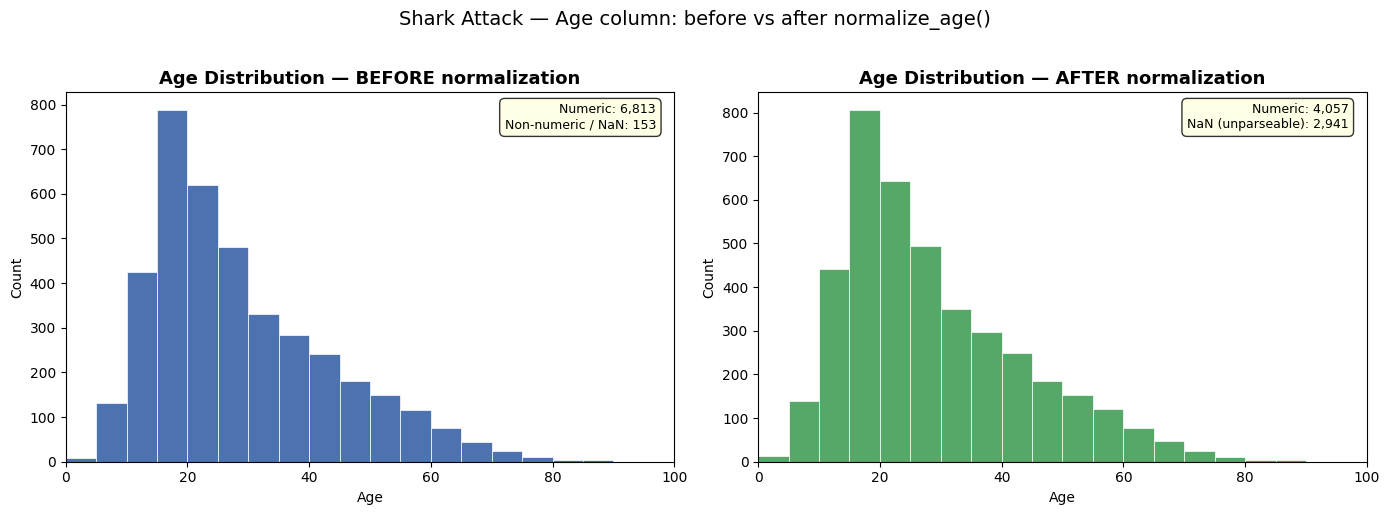

In [298]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import re

# ── 1. Load raw ages BEFORE normalization ─────────────────────────────────────
raw_df = pd.read_csv("normalized_dates.csv", index_col="Unnamed: 0")
raw_age_series = raw_df["age"].astype(str).str.strip()

# Classify each raw value
def is_numeric(v):
    try:
        float(v)
        return True
    except (ValueError, TypeError):
        return False

raw_numeric_mask = raw_age_series.apply(is_numeric)
raw_ages_num = pd.to_numeric(raw_age_series[raw_numeric_mask], errors="coerce").dropna()

# ── 2. Apply normalization and get AFTER ages ─────────────────────────────────
norm_df = normalize_age(raw_df.copy())
norm_ages_num = norm_df["age"].dropna().astype(float)

# ── 3. Summary stats ──────────────────────────────────────────────────────────
total = len(raw_age_series)
raw_nan_count  = (~raw_numeric_mask | raw_age_series.isin(['nan', '?', '', 'M', 'unknown'])).sum()
norm_nan_count = norm_df["age"].isna().sum()

print(f"BEFORE: {total} rows | {int(raw_numeric_mask.sum())} numeric | {total - int(raw_numeric_mask.sum())} non-numeric/unknown")
print(f"AFTER : {len(norm_df)} rows | {len(norm_ages_num)} numeric | {norm_nan_count} NaN")

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

bins = np.arange(0, 101, 5)

# ── Before ──
axes[0].hist(raw_ages_num, bins=bins, color="#4C72B0", edgecolor="white", linewidth=0.5)
axes[0].set_title("Age Distribution — BEFORE normalization", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].set_xlim(0, 100)
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

non_numeric_count = total - int(raw_numeric_mask.sum())
axes[0].text(
    0.97, 0.97,
    f"Numeric: {int(raw_numeric_mask.sum()):,}\nNon-numeric / NaN: {non_numeric_count:,}",
    transform=axes[0].transAxes, ha="right", va="top",
    fontsize=9, bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.8)
)

# ── After ──
axes[1].hist(norm_ages_num, bins=bins, color="#55A868", edgecolor="white", linewidth=0.5)
axes[1].set_title("Age Distribution — AFTER normalization", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")
axes[1].set_xlim(0, 100)
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[1].text(
    0.97, 0.97,
    f"Numeric: {len(norm_ages_num):,}\nNaN (unparseable): {norm_nan_count:,}",
    transform=axes[1].transAxes, ha="right", va="top",
    fontsize=9, bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.8)
)

plt.suptitle("Shark Attack — Age column: before vs after normalize_age()", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [299]:
# Geocode incidents using Nominatim (OpenStreetMap) — free, no API key needed
# pip install geopy  (run once if not installed)

import os
import re
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

CACHE_FILE = "geocache.csv"

# ── Junk values that should be excluded from any query part ──────────────────
JUNK = {
    '', 'nan', 'none', 'unknown', 'n/a', 'na', '?', '-', '--', '.',
    'not stated', 'not known', 'unspecified', 'open ocean', 'open sea',
    'offshore', 'at sea', 'pacific ocean', 'atlantic ocean', 'indian ocean',
    'mediterranean sea', 'caribbean sea', 'south china sea',
}

def clean_field(v):
    """Return the field value if usable, else empty string."""
    if pd.isna(v):
        return ""
    s = str(v).strip().lower()
    # strip punctuation-only strings
    if re.fullmatch(r'[\W_]+', s):
        return ""
    # too short to be meaningful
    if len(s) < 2:
        return ""
    if s in JUNK:
        return ""
    # descriptive phrases that Nominatim can't resolve
    if any(kw in s for kw in ('miles off', 'km off', 'offshore', 'open ocean',
                               'open water', 'at sea', 'reef', 'unnamed')):
        return ""
    return str(v).strip()   # return original casing

# ── Load existing cache ───────────────────────────────────────────────────────
if os.path.exists(CACHE_FILE):
    cache_df = pd.read_csv(CACHE_FILE)
    cache = dict(zip(cache_df["query"], zip(cache_df["lat"], cache_df["lon"])))
else:
    cache = {}

print(f"Cache loaded: {len(cache)} entries")

# ── Setup geocoder ────────────────────────────────────────────────────────────
geolocator = Nominatim(user_agent="shark_attack_eda")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1.1, error_wait_seconds=5)

def try_geocode(location, state, country):
    """Try progressively simpler queries.
    
    Returns (lat, lon, geo_precision) where geo_precision is one of:
      'location' — full query resolved
      'state'    — resolved using state + country only
      'country'  — resolved using country only
      'failed'   — no result at any level
    """
    loc = clean_field(location)
    st  = clean_field(state)
    ctr = clean_field(country)

    # build ordered list of (query_string, precision_label)
    attempts = []
    if loc and ctr:
        q = f"{loc}, {st}, {ctr}" if st else f"{loc}, {ctr}"
        attempts.append((q, "location"))
    if st and ctr:
        attempts.append((f"{st}, {ctr}", "state"))
    if ctr:
        attempts.append((ctr, "country"))

    for q, precision in attempts:
        if q in cache:
            lat, lon = cache[q]
            if lat is None:
                continue            # cached negative result — try next level
            return lat, lon, precision

        result = geocode(q)
        if result:
            cache[q] = (result.latitude, result.longitude)
            return result.latitude, result.longitude, precision
        else:
            cache[q] = (None, None)  # negative cache

    return None, None, "failed"

# ── Build unique location combos ──────────────────────────────────────────────
cols = ["location", "state", "country"]
unique_locs = data[cols].drop_duplicates().reset_index(drop=True)

already_cached = sum(
    1 for _, r in unique_locs.iterrows()
    if f"{clean_field(r['location'])}, {clean_field(r['state'])}, {clean_field(r['country'])}" in cache
)
to_fetch = len(unique_locs) - already_cached
print(f"Unique location combos : {len(unique_locs)}")
print(f"Already cached         : {already_cached}")
print(f"New requests needed    : {to_fetch}  (~{to_fetch} seconds)")


Cache loaded: 38 entries
Unique location combos : 4946
Already cached         : 23
New requests needed    : 4923  (~4923 seconds)


In [300]:
from tqdm import tqdm

SAVE_EVERY = 25   # flush cache to disk every N new geocode calls

lats, lons, precisions = [], [], []
new_since_save = 0

with tqdm(unique_locs.iterrows(), total=len(unique_locs), desc="Geocoding", unit="loc") as pbar:
    for i, row in pbar:
        lat, lon, precision = try_geocode(row["location"], row["state"], row["country"])
        lats.append(lat)
        lons.append(lon)
        precisions.append(precision)

        # update progress bar suffix with latest result
        loc_preview = str(row["location"])[:30]
        coord_str = f"({lat:.2f}, {lon:.2f})" if lat is not None else "—"
        pbar.set_postfix_str(f"[{precision}] {loc_preview} {coord_str}", refresh=True)

        # count genuinely new requests (not cache hits)
        if lat is not None or precision == "failed":
            new_since_save += 1

        # periodic cache save
        if new_since_save >= SAVE_EVERY:
            cache_rows = [{"query": q, "lat": v[0], "lon": v[1]} for q, v in cache.items()]
            pd.DataFrame(cache_rows).to_csv(CACHE_FILE, index=False)
            print(f"  ✓ Cache saved ({len(cache_rows)} entries)")
            new_since_save = 0

# ── Final cache save ──────────────────────────────────────────────────────────
cache_rows = [{"query": q, "lat": v[0], "lon": v[1]} for q, v in cache.items()]
pd.DataFrame(cache_rows).to_csv(CACHE_FILE, index=False)
print(f"Cache saved: {len(cache_rows)} entries → {CACHE_FILE}")

# ── Merge back into main dataframe ───────────────────────────────────────────
unique_locs["lat"]           = lats
unique_locs["lon"]           = lons
unique_locs["geo_precision"] = precisions

data = data.merge(
    unique_locs[["location", "state", "country", "lat", "lon", "geo_precision"]],
    on=["location", "state", "country"], how="left"
)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nTotal rows: {len(data):,}")
print("\ngeo_precision breakdown:")
print(data["geo_precision"].value_counts(dropna=False).to_string())
resolved = data["lat"].notna().sum()
print(f"\nRows with coordinates: {resolved:,} / {len(data):,} ({resolved/len(data)*100:.1f}%)")


Geocoding:   0%|          | 0/4946 [00:00<?, ?loc/s, [location] Catalina Island (nan, nan)]                     

  ✓ Cache saved (38 entries)


Geocoding:   1%|          | 49/4946 [00:36<1:26:39,  1.06s/loc, [location] Sunset Beach (33.88, -78.51)]                   

  ✓ Cache saved (70 entries)


Geocoding:   2%|▏         | 75/4946 [01:19<2:05:25,  1.55s/loc, [country] ? (-19.30, 34.91)]                            

...

  ✓ Cache saved (5153 entries)


Geocoding: 100%|█████████▉| 4925/4946 [1:36:33<00:25,  1.20s/loc, [country] 18.8S, 178.25E (-18.12, 179.01)]             

  ✓ Cache saved (5178 entries)


Geocoding: 100%|██████████| 4946/4946 [1:36:58<00:00,  1.18s/loc, [country] Below the English fort, Trinco (7.56, 80.71)]  

Cache saved: 5200 entries → geocache.csv

Total rows: 6,999

geo_precision breakdown:
geo_precision
location    3552
state       2635
country      667
failed       145

Rows with coordinates: 6,842 / 6,999 (97.8%)


In [301]:
data.to_csv("preprocessed.csv")